In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
print(Path.cwd())

C:\Users\spand\Desktop\mini projects


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from pathlib import Path

data_folder = Path(r"C:\Users\spand\Desktop\mini projects\diabatic project\data set")

print("Files in dataset folder:")

for file in data_folder.iterdir():
    print(file.name)

Files in dataset folder:
diabetes.csv


In [6]:
data_path = Path(
    r"C:\Users\spand\Desktop\mini projects\diabatic project\data set\diabetes.csv"
)

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (768, 9)


In [7]:
data_path = Path(
    r"C:\Users\spand\Desktop\mini projects\diabatic project\data set\Diabetes.csv"
)

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (768, 9)


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 9


In [9]:
from pathlib import Path

data_folder = Path(
    r"C:\Users\spand\Desktop\mini projects\diabatic project\data set"
)

print("Dataset folder:")
print(data_folder)

Dataset folder:
C:\Users\spand\Desktop\mini projects\diabatic project\data set


In [10]:
csv_files = list(data_folder.glob("*.csv"))

print("CSV files found:")

for file in csv_files:
    print(file)

CSV files found:
C:\Users\spand\Desktop\mini projects\diabatic project\data set\diabetes.csv


In [11]:
import pandas as pd

data_path = csv_files[0]

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (768, 9)


In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [13]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 768
Columns: 9


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [16]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [18]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [19]:
print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [20]:
df_clean = df.copy()

print("Copy created successfully.")

Copy created successfully.


In [21]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [22]:
df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (768, 9)


In [23]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [24]:
df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (768, 9)


In [25]:
print(df_clean.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [26]:
print(df_clean.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

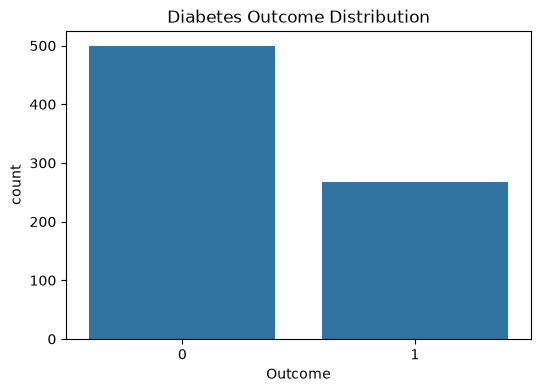

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Outcome",
    data=df_clean
)

plt.title("Diabetes Outcome Distribution")
plt.show()

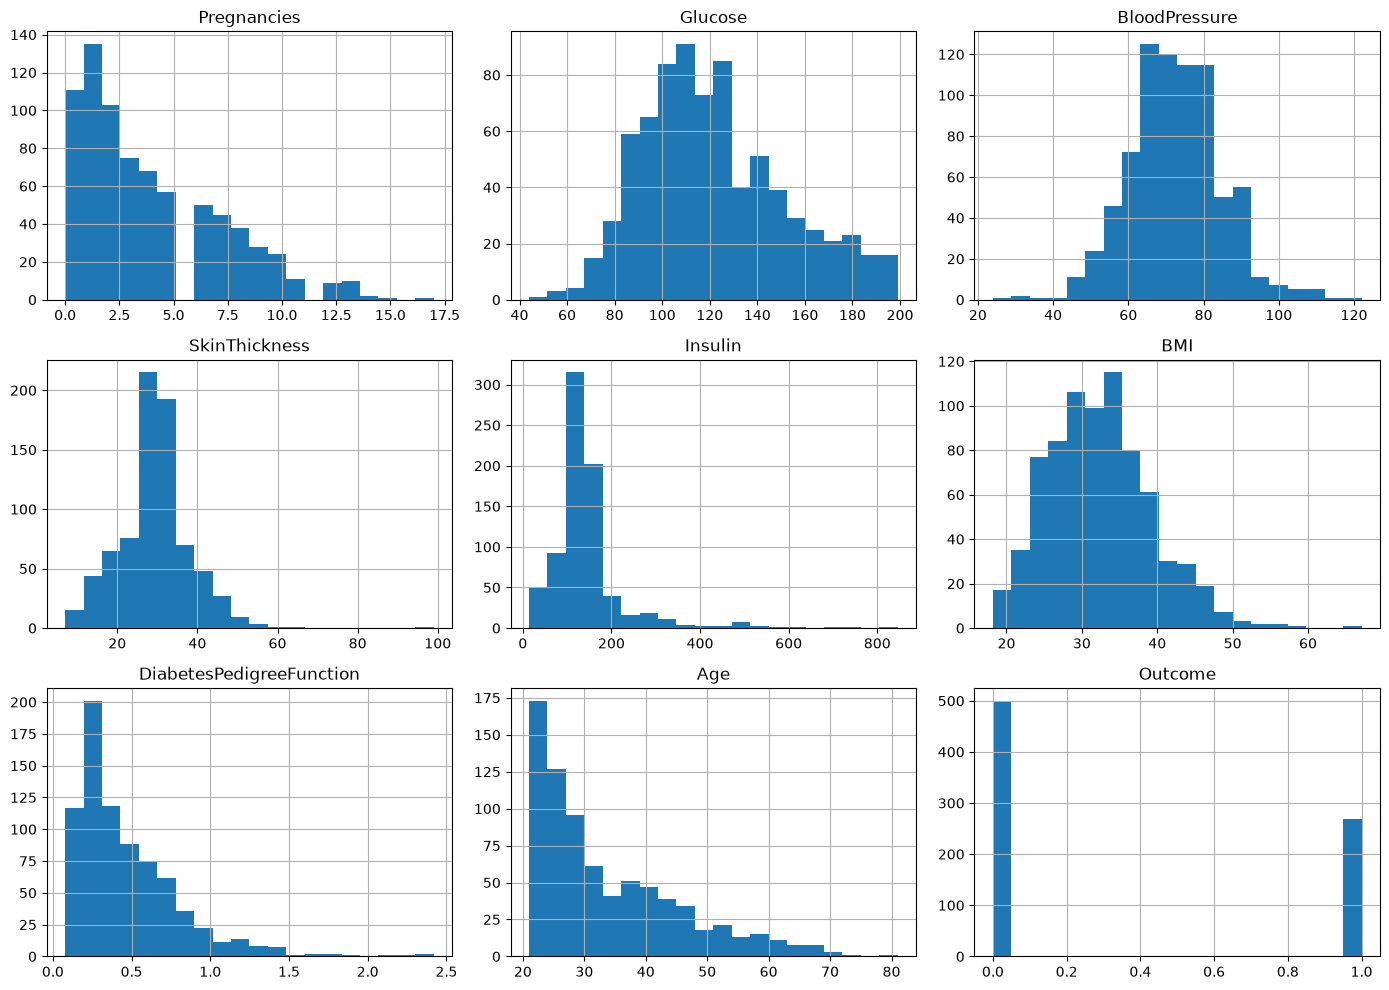

In [29]:
df_clean.hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()
plt.show()

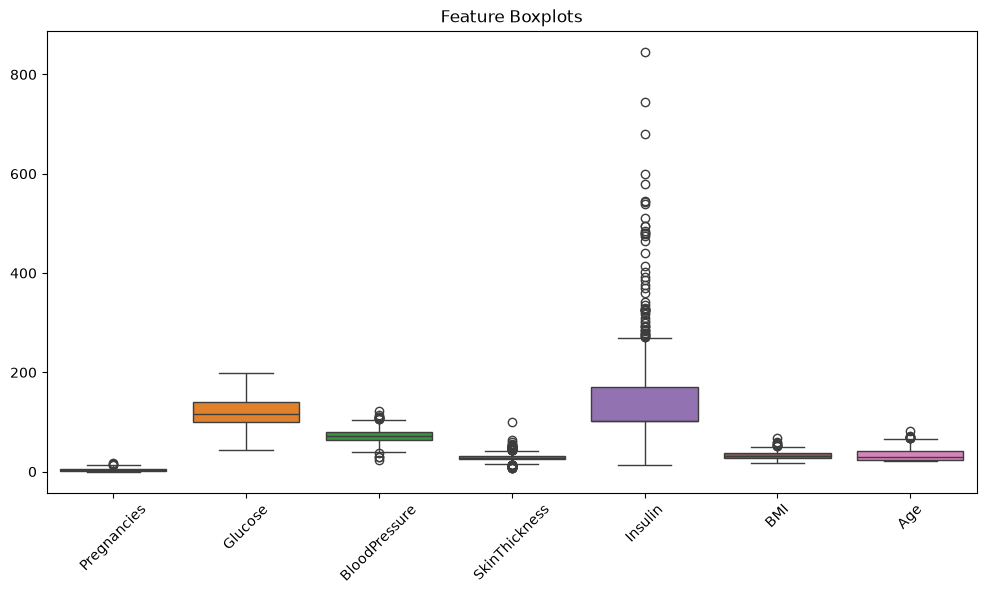

In [30]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_clean[
        [
            "Pregnancies",
            "Glucose",
            "BloodPressure",
            "SkinThickness",
            "Insulin",
            "BMI",
            "Age"
        ]
    ]
)

plt.xticks(rotation=45)
plt.title("Feature Boxplots")

plt.show()

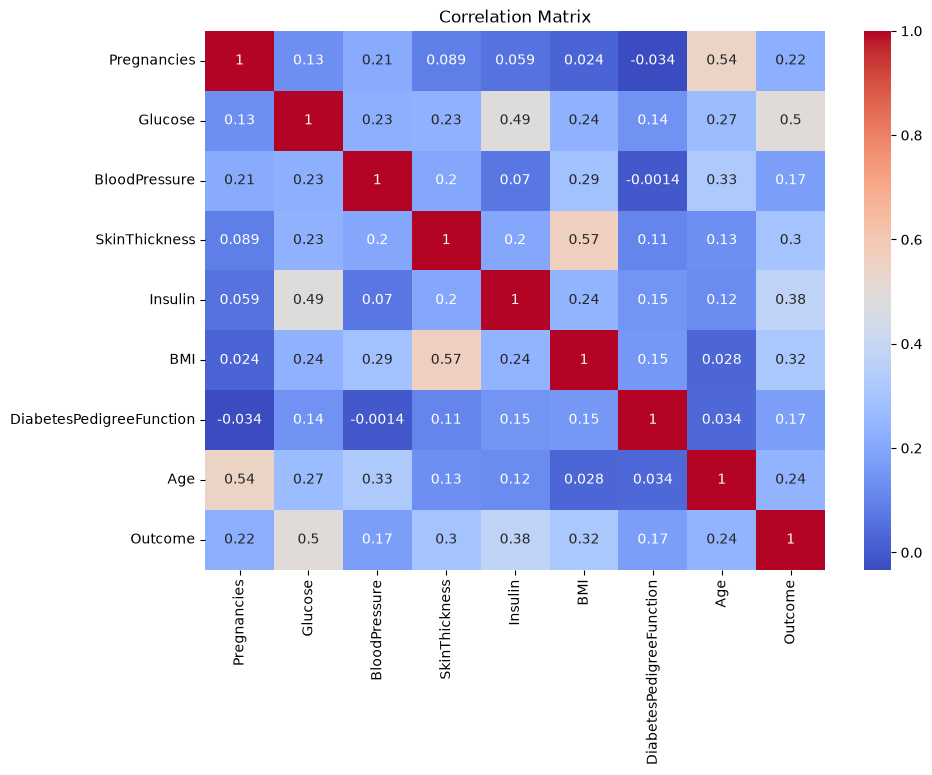

In [31]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [32]:
X = df_clean.drop(
    "Outcome",
    axis=1
)

y = df_clean["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (614, 8)
Testing: (154, 8)


In [34]:
from sklearn.preprocessing import StandardScaler

In [38]:
Pregnancies = 2
Glucose = 140
BloodPressure = 72
SkinThickness = 35
Insulin = 0
BMI = 32
DiabetesPedigreeFunction = 0.5
Age = 45

In [40]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (768, 8)
Output shape: (768,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Model libraries imported successfully!")

Model libraries imported successfully!


In [43]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC())
    ])
}

print("5 models created successfully!")

5 models created successfully!


In [44]:
results = []
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    trained_models[name] = model

    print(name, "completed")

print("\nAll models trained successfully!")

Logistic Regression completed
KNN completed
Decision Tree completed
Random Forest completed
SVM completed

All models trained successfully!


In [45]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.707792,0.588235,0.555556,0.571429
1,KNN,0.811688,0.735849,0.722222,0.728972
2,Decision Tree,0.811688,0.745098,0.703704,0.723810
3,Random Forest,0.863636,0.811321,0.796296,0.803738
4,SVM,0.837662,0.763636,0.777778,0.770642


In [46]:
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
3,Random Forest,0.863636,0.811321,0.796296,0.803738
4,SVM,0.837662,0.763636,0.777778,0.770642
1,KNN,0.811688,0.735849,0.722222,0.728972
2,Decision Tree,0.811688,0.745098,0.703704,0.723810
0,Logistic Regression,0.707792,0.588235,0.555556,0.571429


In [48]:
results_df

,Model,Accuracy,Precision,Recall,F1-Score
3,Random Forest,0.863636,0.811321,0.796296,0.803738
4,SVM,0.837662,0.763636,0.777778,0.770642
1,KNN,0.811688,0.735849,0.722222,0.728972
2,Decision Tree,0.811688,0.745098,0.703704,0.723810
0,Logistic Regression,0.707792,0.588235,0.555556,0.571429


In [49]:
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
3,Random Forest,0.863636,0.811321,0.796296,0.803738
4,SVM,0.837662,0.763636,0.777778,0.770642
1,KNN,0.811688,0.735849,0.722222,0.728972
2,Decision Tree,0.811688,0.745098,0.703704,0.723810
0,Logistic Regression,0.707792,0.588235,0.555556,0.571429


In [50]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [51]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[90 10]
 [11 43]]


In [52]:
prediction_results = X_test.copy()

prediction_results["Actual_Outcome"] = y_test.values
prediction_results["Predicted_Outcome"] = y_pred_best

prediction_results.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual_Outcome,Predicted_Outcome
44,7,159,64.0,27,102.5,27.4,0.294,40,0,0
672,10,68,106.0,23,49.0,35.5,0.285,47,0,0
700,2,122,76.0,27,200.0,35.9,0.483,26,0,0
630,7,114,64.0,32,169.5,27.4,0.732,34,1,1
81,2,74,70.0,27,102.5,30.1,0.102,22,0,0
